<h1 style = "color : green"> Standardization or Z-score normalization

In [1]:
# importing required libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
# loading dataset 

df = pd.read_csv('Social_Network_Ads.csv', usecols = ['Age', 'EstimatedSalary', 'Purchased'])
df.sample(5)

,Age,EstimatedSalary,Purchased
319,36,60000,0
101,28,59000,0
102,32,86000,0
381,48,33000,1
14,18,82000,0


<h2 style = 'color : green'>Train Test split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis = 1), df['Purchased'], test_size = 0.3, random_state = 42)

X_test.shape, X_train.shape
X_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


<h2 style = "color : green">StandardScaler</h2>

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)


StandardScaler()

In [13]:
# transforming the train and test set 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [20]:
X_train_scaled    # this is an array containing the features so we need to convert it to dataframe   

array([[-0.84252154,  0.1301563 ],
       [ 0.04175763,  0.2777019 ],
       [ 0.72953032, -1.31579061],
       [ 1.61380949,  1.10395728],
       [ 0.82778356, -1.40431797],
       [-1.43204099, -1.25677236],
       [-0.05649561,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 ,  0.01211982],
       [ 1.31904976,  2.22530386],
       [ 0.14001087,  0.74984783],
       [-1.33378775,  0.54328399],
       [ 2.00682245,  0.72033871],
       [-1.23553451, -1.43382709],
       [ 0.33651735, -0.34198963],
       [-0.94077478,  0.54328399],
       [ 0.43477059,  0.2777019 ],
       [ 0.43477059,  1.10395728],
       [ 0.82778356,  0.74984783],
       [ 0.9260368 ,  1.25150288],
       [-0.44950858, -1.25677236],
       [-1.82505395, -1.34529973],
       [ 1.12254328,  0.54328399],
       [-0.64601506, -1.64039093],
       [-0.7442683 ,  0.24819278],
       [ 1.02429004,  2.07775825],
       [-0.54776182,  1.36953936],
       [-0.05649561,  0.01211982],
       [-1.9233072 ,

In [22]:
# converting the scaled arrays to data frames

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [24]:
# statistical details before scaling

np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [26]:
# ststical ddetails after scaling 

np.round(X_train_scaled.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.92,-1.64
25%,-0.74,-0.78
50%,-0.06,0.01
75%,0.73,0.51
max,2.20,2.34


<h2 style = "color : green">Before and After effect of scaling

<function matplotlib.pyplot.show(close=None, block=None)>

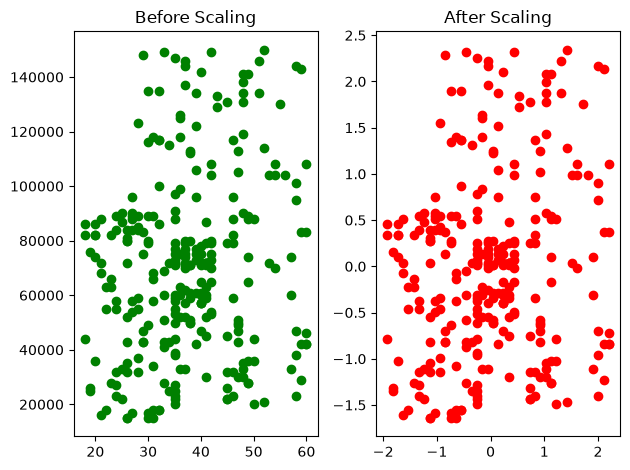

In [40]:
# Before Scaling
plt.subplot(1, 2, 1)
plt.scatter(x = X_train['Age'], y = X_train['EstimatedSalary'], color = 'green')
plt.title('Before Scaling')

# After Scaling
plt.subplot(1, 2, 2)
plt.scatter(x = X_train_scaled['Age'], y = X_train_scaled['EstimatedSalary'], color = 'red')
plt.title('After Scaling')

plt.tight_layout()
plt.show

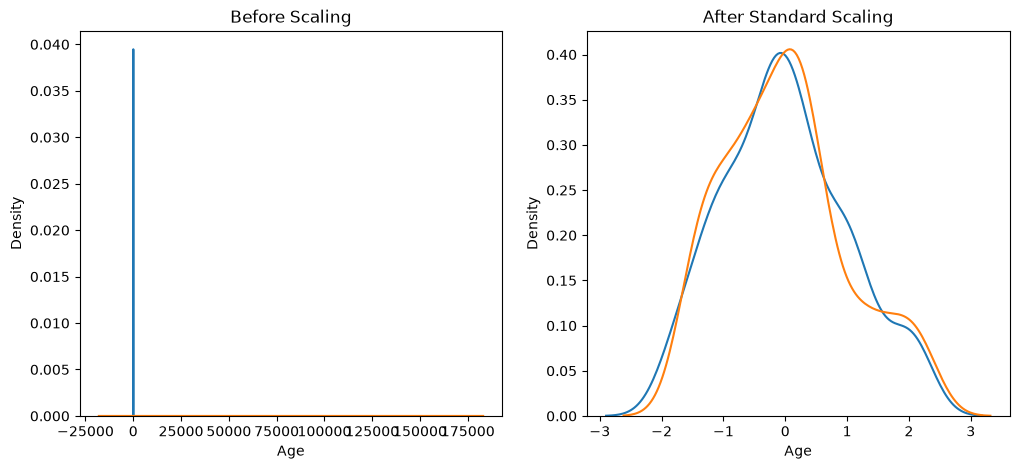

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(data = X_train, x = 'Age', ax=ax1)
sns.kdeplot(data = X_train, x = 'EstimatedSalary', ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(data = X_train_scaled, x = 'Age', ax=ax2)
sns.kdeplot(data = X_train_scaled, x = 'EstimatedSalary', ax=ax2)
plt.show()

<h2 style = "color : green">Comparison of Distributions

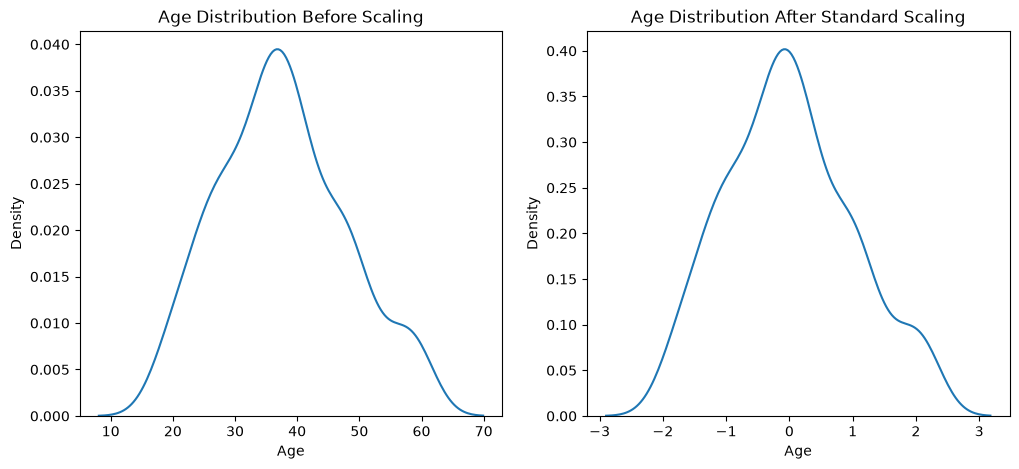

In [55]:
# Comparing Age

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

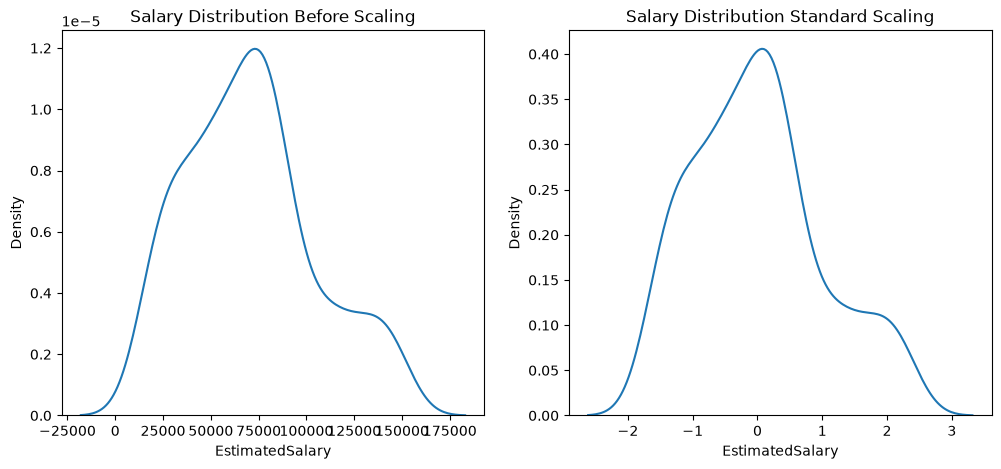

In [54]:
# Comparing Estimated Salary

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()